[![Labellerr](https://storage.googleapis.com/labellerr-cdn/%200%20Labellerr%20template/notebook.webp)](https://www.labellerr.com)

# **Egocentric Construction Step Tracking**

---

[![labellerr](https://img.shields.io/badge/Labellerr-BLOG-black.svg)](https://www.labellerr.com/blog/<BLOG_NAME>)
[![Youtube](https://img.shields.io/badge/Labellerr-YouTube-b31b1b.svg)](https://www.youtube.com/@Labellerr)
[![Github](https://img.shields.io/badge/Labellerr-GitHub-green.svg)](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)

## Project Overview  
POV Construction Step Timeline Detector is an AI-powered computer vision system designed to automatically analyze and segment first-person construction and carpentry videos into structured timelines.

The system combines:
- Global construction scene classification  

to detect construction phases such as:
- Wearing Gloves
- Carrying & Placing Wooden Plank
- Using NailGun
- Measuring & Marking Area
- Cutting Wooden Plank
- Refilling Nails & Connecting Wire

By integrating scene understanding with hand-motion analysis, the model generates a continuous and intelligent timeline directly from raw POV construction footage.

---

## Core Architecture  

### Global Scene Recognition  
Identifies the current construction phase based on the full workbench and environment.

### Temporal Timeline Mapping  
Combines scene transitions and hand actions to build a chronological construction workflow.

### Structured Video Understanding  
Transforms unstructured construction footage into searchable and segmented procedural data.

---

## Real-World Applications  

### Automated Workflow Tracking  
Generates timestamps and chapter markers for construction tasks and compliance monitoring.

### Safety & Ergonomics Analysis  
Evaluates tool handling and hand coordination for safety assessment.

### Video Search & Indexing  
Allows direct navigation to moments like cutting, measuring, or nailing within long footage.

---

## Annotate your Custom dataset using Labellerr

 ***1. Visit the [Labellerr](https://www.labellerr.com/?utm_source=githubY&utm_medium=social&utm_campaign=github_clicks) website and click **“Sign Up”**.*** 

 ***2. After signing in, create your workspace by entering a unique name.***

 ***3. Navigate to your workspace’s API keys page (e.g., `https://<your-workspace>.labellerr.com/workspace/api-keys`) to generate your **API Key** and **API Secret**.***

 ***4. Store the credentials securely, and then use them to initialise the SDK or API client with `api_key`, `api_secret`.*** 


## Import Libraries

This section imports all the required libraries used throughout the project for computer vision, visualization, deep learning, and structured coding.

In [ ]:
!git clone https://github.com/Labellerr/yolo_finetune_utils.git

In [ ]:
!pip install ultralytics opencv-python matplotlib cv2

## 📥 Download Annotations from Labellerr

After completing data labeling on the **Labellerr** platform, export the annotations in **COCO JSON format**.

Download the COCO JSON file from the Labellerr website and upload it into this project workspace to use it for further dataset preparation and training.

This COCO JSON file will be used in the next steps for:
- Frame–annotation alignment
- COCO → YOLO format conversion
- Model training and evaluation

---

# COCO to YOLO Format Conversion

Converts COCO-style segmentation annotations to YOLO classification dataset format.  
- Requires: `annotation.json` and images in `frames_output` directory.
- Output: Generated YOLO dataset folder.
- Parameters: allows train/val split, shuffling, and verbose mode.

In [ ]:
import os
import cv2
import json
import random

# --- CONFIGURATION ---
VIDEO_PATH = "pov_omlete_making.mp4"
JSON_PATH = "export-#6bf41ee5-d187-4345-b1eb-f44cc9610cd0.json"
OUTPUT_DIR = "kitchen_dataset"
FRAME_STRIDE = 3  # Save every 3rd frame to prevent redundancy

# 1. Load the Labellerr JSON structure
with open(JSON_PATH, "r") as f:
    raw_data = json.load(f)

# The video asset blocks sit inside the first element array
video_entry = raw_data[0]
latest_answers = video_entry.get("file_metadata", {})
video_fps = latest_answers.get("fps", 23)  # Pulls the 23 FPS straight from your file metadata

# 2. Extract and parse event segments from answers
parsed_events = []
for question_block in video_entry.get("latest_answer", []):
    event_label = question_block.get("question_name").replace(" ", "_")
    
    # Iterate through all occurrences of this event
    for segment in question_block.get("answer", []):
        start_frame = int(segment.get("startFrame"))
        end_frame = int(segment.get("endFrame"))
        
        parsed_events.append({
            "label": event_label,
            "start_frame": start_frame,
            "end_frame": end_frame
        })

print(f"Successfully extracted {len(parsed_events)} event segments from Labellerr JSON.")

# 3. Dynamically build YOLO class classification folders
splits = ['train', 'val']
for split in splits:
    for event in parsed_events:
        os.makedirs(os.path.join(OUTPUT_DIR, split, event["label"]), exist_ok=True)

# 4. Process the Video Frames via Frame Index Tracking
cap = cv2.VideoCapture(VIDEO_PATH)
frame_count = 0

print(f"Processing video at {video_fps} FPS...")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    # Check if the current frame matches any parsed event boundaries
    assigned_event = None
    for event in parsed_events:
        if event["start_frame"] <= frame_count <= event["end_frame"]:
            assigned_event = event["label"]
            break  # Break out early if found
            
    if assigned_event and (frame_count % FRAME_STRIDE == 0):
        # 80/20 train/validation assignment
        split = "train" if random.random() < 0.80 else "val"
        
        frame_name = f"frame_{frame_count:06d}.jpg"
        save_path = os.path.join(OUTPUT_DIR, split, assigned_event, frame_name)
        cv2.imwrite(save_path, frame)
            
    frame_count += 1

cap.release()
print(f"🚀 YOLO Classification Dataset compiled successfully inside: '{OUTPUT_DIR}/'")

# YOLO11 Event Model Training

- Fine-tunes a custom **YOLO11-Classification** model using `yolo11n-cls.pt`.  
- Trains on the extracted event frames dataset for **50 epochs** at **640px** resolution using GPU acceleration (`device=0`).  
- Uses **4 workers** for faster batch loading.  
- Saves optimized weights (`best.pt`, `last.pt`) to:

`runs/classify/train/weights/`

---


In [ ]:
from ultralytics import YOLO

# Load a lightweight pre-trained classification model for event tagging
model = YOLO("yolo11n-cls.pt") 

# Train on your custom construction event frames
results = model.train(
    data="construction_dataset", # Make sure this matches your OUTPUT_DIR from the dataset conversion step
    epochs=50,             
    imgsz=640,             
    batch=16,              
    device=0,               # 0 runs natively on your GPU; change to 'cpu' if you don't have a GPU
    workers=4              
)


# Real-Time Event Inference Pipeline

- Loads the custom YOLO11 Event Tagging model (`best.pt`).
- Performs real-time construction step recognition on the input video stream.
- Displays a clean, dynamic dashboard showing the current construction stage:
  - Wearing Gloves  
  - Carry Wooden Plank  
  - Placing the Plank  
  - Using NailGun  
  - Connecting Wire  
  - Measuring  
  - Marking Area  
  - Cutting Wooden Plank  
  - Refilling Nails  
- Renders an opaque black overlay text box at the top left of the screen for tracking status.
- Processes the video frame-by-frame with a live preview window.

---

![Real-Time Event Inference Pipeline](attachment:Screenshot%202026-09-04%20015004.png)

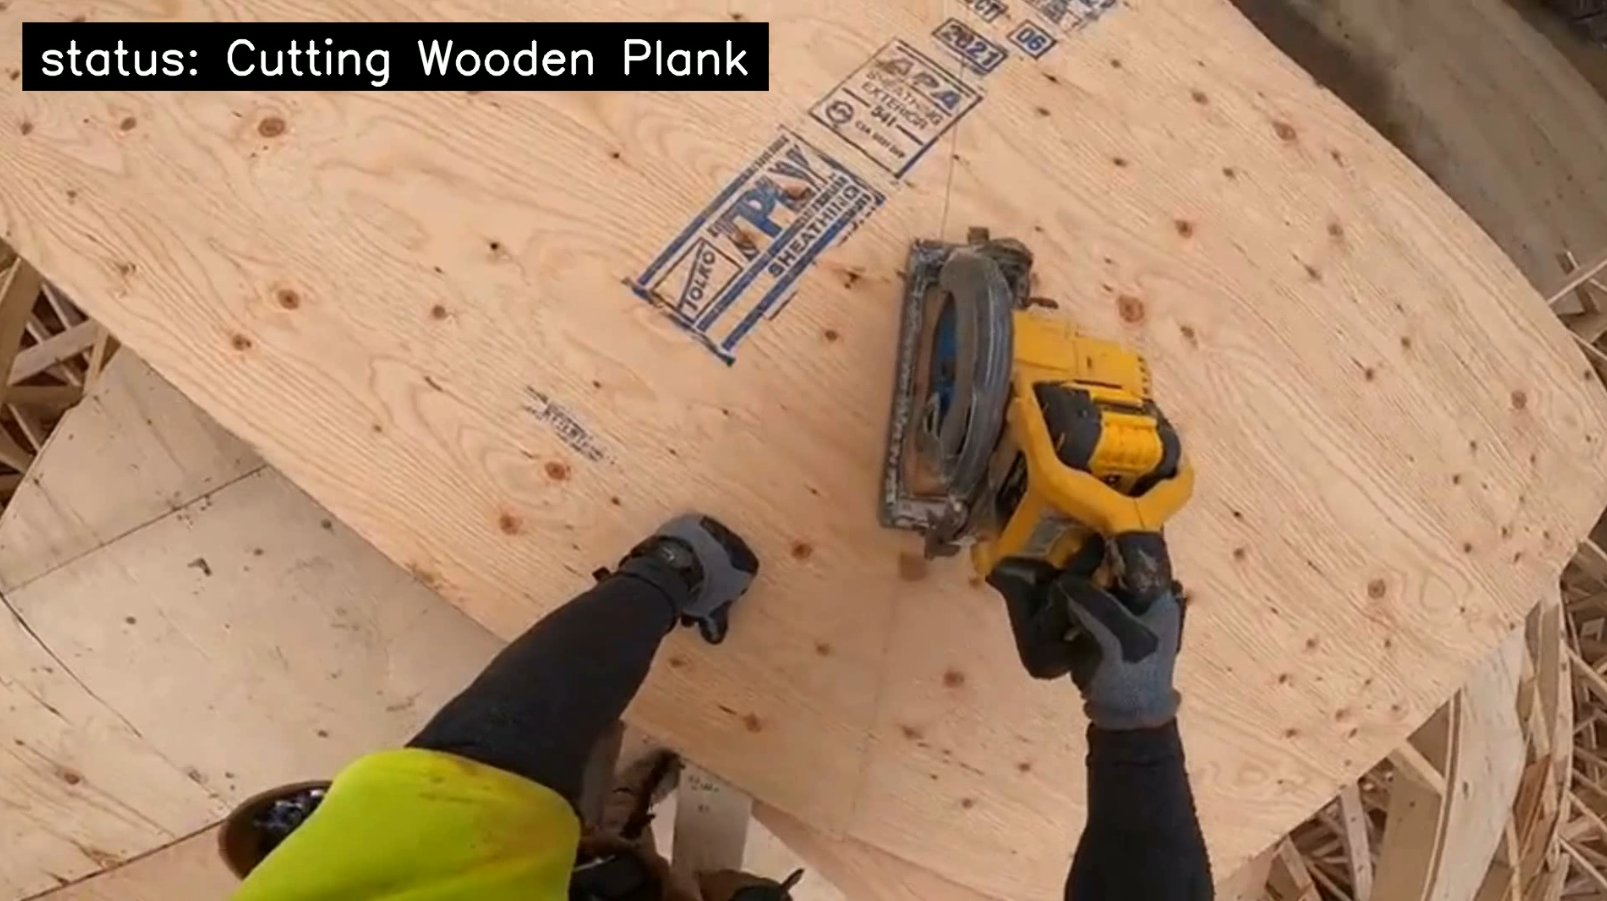

In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO

# --- CONFIGURATION ---
VIDEO_PATH = "Construction Egocentric.mp4"
CLASSIFY_MODEL_PATH = "best.pt"  # Your Event classification model

# 1. Load custom trained event model
print("Loading custom YOLO11 Event model...")
event_model = YOLO(CLASSIFY_MODEL_PATH)

# Define your construction event clean display mappings
# This maps the raw YOLO class names (with underscores) back to clean display text
EVENT_DISPLAY_NAMES = {
    "Wearing_Gloves": "Wearing Gloves",
    "Carry_Wooden_Plank": "Carry Wooden Plank",
    "Placing_the_Plank": "Placing the Plank",
    "Using_NailGun": "Using NailGun",
    "Connecting_Wire": "Connecting Wire",
    "Refilling_Nails": "Refilling Nails",
    "Measuring": "Measuring",
    "Marking_Area": "Marking Area",
    "Cutting_Wooden_Plank": "Cutting Wooden Plank",
    "carrying_Wooden_Plank": "Carrying Wooden Plank"
}

# 2. Open Video Stream
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    print(f"Error: Could not open video file {VIDEO_PATH}")
    exit()

print("Starting inference loop. Press 'q' to exit.")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
        
    # --- STEP 1: GLOBAL EVENT TAGGING ---
    event_results = event_model(frame, verbose=False)
    
    # Extract the highest probability class name
    raw_class_name = event_results[0].names[event_results[0].probs.top1]
    
    # Clean up the name mapping for display
    display_status = EVENT_DISPLAY_NAMES.get(raw_class_name, raw_class_name)
    status_text = f"status: {display_status.lower()}"
    
    # --- STEP 2: RENDER BLACK BOX TEXT OVERLAY ---
    # Setup text sizing configurations dynamically to fit the background box
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1.5  # Slightly larger for clear visibility
    thickness = 3
    text_color = (255, 255, 255)  # White text
    
    # Calculate exact pixels needed for the text boundaries
    (text_w, text_h), baseline = cv2.getTextSize(status_text, font, font_scale, thickness)
    
    # Define box dimensions padding metrics
    padding_x = 20
    padding_y = 20
    box_x1 = 20
    box_y1 = 20
    box_x2 = box_x1 + text_w + (padding_x * 2)
    box_y2 = box_y1 + text_h + (padding_y * 2)
    
    # Render the opaque black bounding background rectangle box
    cv2.rectangle(frame, (box_x1, box_y1), (box_x2, box_y2), (0, 0, 0), cv2.FILLED)
    
    # Calculate text origin point coordinate line offset anchor
    text_org_x = box_x1 + padding_x
    text_org_y = box_y1 + text_h + padding_y
    
    # Write text cleanly over the black box region
    cv2.putText(frame, status_text, (text_org_x, text_org_y), font, font_scale, text_color, thickness, cv2.LINE_AA)
    
    # --- STEP 3: PREVIEW DISPLAY WINDOW ---
    # Optional window resize safety boundary in case frame dimensions exceed monitors
    cv2.imshow("Construction Step Detector - Real-time Pipeline", frame)
    
    # Break frame process loop safely if user triggers 'q' key threshold escape
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print("Pipeline execution stopped successfully.")


---

## 👨‍💻 About Labellerr's Hands-On Learning in Computer Vision

Thank you for exploring this **Labellerr Hands-On Computer Vision Cookbook**! We hope this notebook helped you learn, prototype, and accelerate your vision projects.  
Labellerr provides ready-to-run Jupyter/Colab notebooks for the latest models and real-world use cases in computer vision, AI agents, and data annotation.

---
## 🧑‍🔬 Check Our Popular Youtube Videos

Whether you're a beginner or a practitioner, our hands-on training videos are perfect for learning custom model building, computer vision techniques, and applied AI:

- [How to Fine-Tune YOLO on Custom Dataset](https://www.youtube.com/watch?v=pBLWOe01QXU)  
  Step-by-step guide to fine-tuning YOLO for real-world use—environment setup, annotation, training, validation, and inference.
- [Build a Real-Time Intrusion Detection System with YOLO](https://www.youtube.com/watch?v=kwQeokYDVcE)  
  Create an AI-powered system to detect intruders in real time using YOLO and computer vision.
- [Finding Athlete Speed Using YOLO](https://www.youtube.com/watch?v=txW0CQe_pw0)  
  Estimate real-time speed of athletes for sports analytics.
- [Object Counting Using AI](https://www.youtube.com/watch?v=smsjBBQcIUQ)  
  Learn dataset curation, annotation, and training for robust object counting AI applications.
---

## 🎦 Popular Labellerr YouTube Videos

Level up your skills and see video walkthroughs of these tools and notebooks on the  
[Labellerr YouTube Channel](https://www.youtube.com/@Labellerr/videos):

- [How I Fixed My Biggest Annotation Nightmare with Labellerr](https://www.youtube.com/watch?v=hlcFdiuz_HI) – Solving complex annotation for ML engineers.
- [Explore Your Dataset with Labellerr's AI](https://www.youtube.com/watch?v=LdbRXYWVyN0) – Auto-tagging, object counting, image descriptions, and dataset exploration.
- [Boost AI Image Annotation 10X with Labellerr's CLIP Mode](https://www.youtube.com/watch?v=pY_o4EvYMz8) – Refine annotations with precision using CLIP mode.
- [Boost Data Annotation Accuracy and Efficiency with Active Learning](https://www.youtube.com/watch?v=lAYu-ewIhTE) – Speed up your annotation workflow using Active Learning.

> 👉 **Subscribe** for Labellerr's deep learning, annotation, and AI tutorials, or watch videos directly alongside notebooks!

---

## 🤝 Stay Connected

- **Website:** [https://www.labellerr.com/](https://www.labellerr.com/)
- **Blog:** [https://www.labellerr.com/blog/](https://www.labellerr.com/blog/)
- **GitHub:** [Labellerr/Hands-On-Learning-in-Computer-Vision](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)
- **LinkedIn:** [Labellerr](https://in.linkedin.com/company/labellerr)
- **Twitter/X:** [@Labellerr1](https://x.com/Labellerr1)

*Happy learning and building with Labellerr!*